In [147]:
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, AvgPool2D
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from matplotlib import style
#style.use("classic")
#style.use("fivethirtyeight")
style.use("ggplot")
from tqdm import trange

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

import random

from numpy import expand_dims
from tensorflow.keras.preprocessing.image import img_to_array

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 56

## Задание 1

Постройте нейронную сеть из одного нейрона и обучите её на датасетах nn_0.csv и nn_1.csv. Насколько отличается результат обучения и почему? Сколько потребовалось эпох для обучения? Попробуйте различные функции активации и оптимизаторы. 

In [149]:
data0 = pd.read_csv('nn_0.csv')
data1 = pd.read_csv('nn_1.csv')

In [150]:
display(data0.head(3))
data1.head(3)

,X1,X2,class
0,1.017522,1.543864,-1
1,1.151304,1.724181,-1
2,1.050958,1.119564,-1


,X1,X2,class
0,-0.011802,0.040455,1
1,-0.178221,0.212999,1
2,0.061962,0.186818,1


Метрика бинарная кросс-энтропия работает с классами 1 и 0, а у нас 1 и -1

In [151]:
data0['class'] = data0['class'].apply(lambda x: 1 if x==1 else 0)
data1['class'] = data1['class'].apply(lambda x: 1 if x==1 else 0)

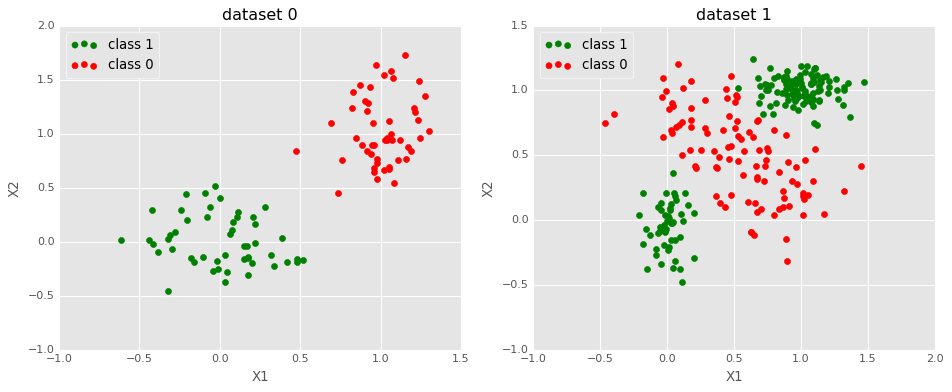

In [153]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
axes[0].scatter(data0.loc[data0['class']==1, 'X1'], data0.loc[data0['class']==1, 'X2'], label='class 1', color='green', s=30)
axes[0].scatter(data0.loc[data0['class']==0, 'X1'], data0.loc[data0['class']==0, 'X2'], label='class 0', color='red', s=30)
axes[0].set_title('dataset 0')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].legend(loc='upper left')
axes[1].scatter(data1.loc[data1['class']==1, 'X1'], data1.loc[data1['class']==1, 'X2'], label='class 1', color='green', s=30)
axes[1].scatter(data1.loc[data1['class']==0, 'X1'], data1.loc[data1['class']==0, 'X2'], label='class 0', color='red', s=30)
axes[1].set_title('dataset 1')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')
axes[1].legend(loc='upper left')
plt.tight_layout()
plt.show()

In [154]:
X_train0, X_test0, y_train0, y_test0 = train_test_split(
    data0.drop('class', axis=1),
    data0['class'],
    random_state=RANDOM_STATE
)

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    data1.drop('class', axis=1),
    data1['class'],
    random_state=RANDOM_STATE
)

In [155]:
def train_model(X_train, y_train, X_test, y_test, learning_rate=0.001):
    res_dict = {}
    for optimizer_name in ['sgd', 'adam']:
        for activation in ['sigmoid', 'tanh']:
            if optimizer_name == 'adam':
                optimizer = Adam(learning_rate)
            else:
                optimizer =  keras.optimizers.SGD()
            model = keras.models.Sequential()
            model.add(Dense(
                units=1, input_dim=2, activation=activation,
                #kernel_initializer=keras.initializers.GlorotUniform(seed=RANDOM_STATE),
                #bias_initializer=keras.initializers.Zeros()
            ))
            model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
            res_dict[optimizer_name + '_' + activation] = model.fit(X_train, y_train, verbose=0, epochs=100, validation_data=(X_test, y_test), shuffle=True).history
    return res_dict

In [156]:
train0 = train_model(X_train0, y_train0, X_test0, y_test0, 0.01)

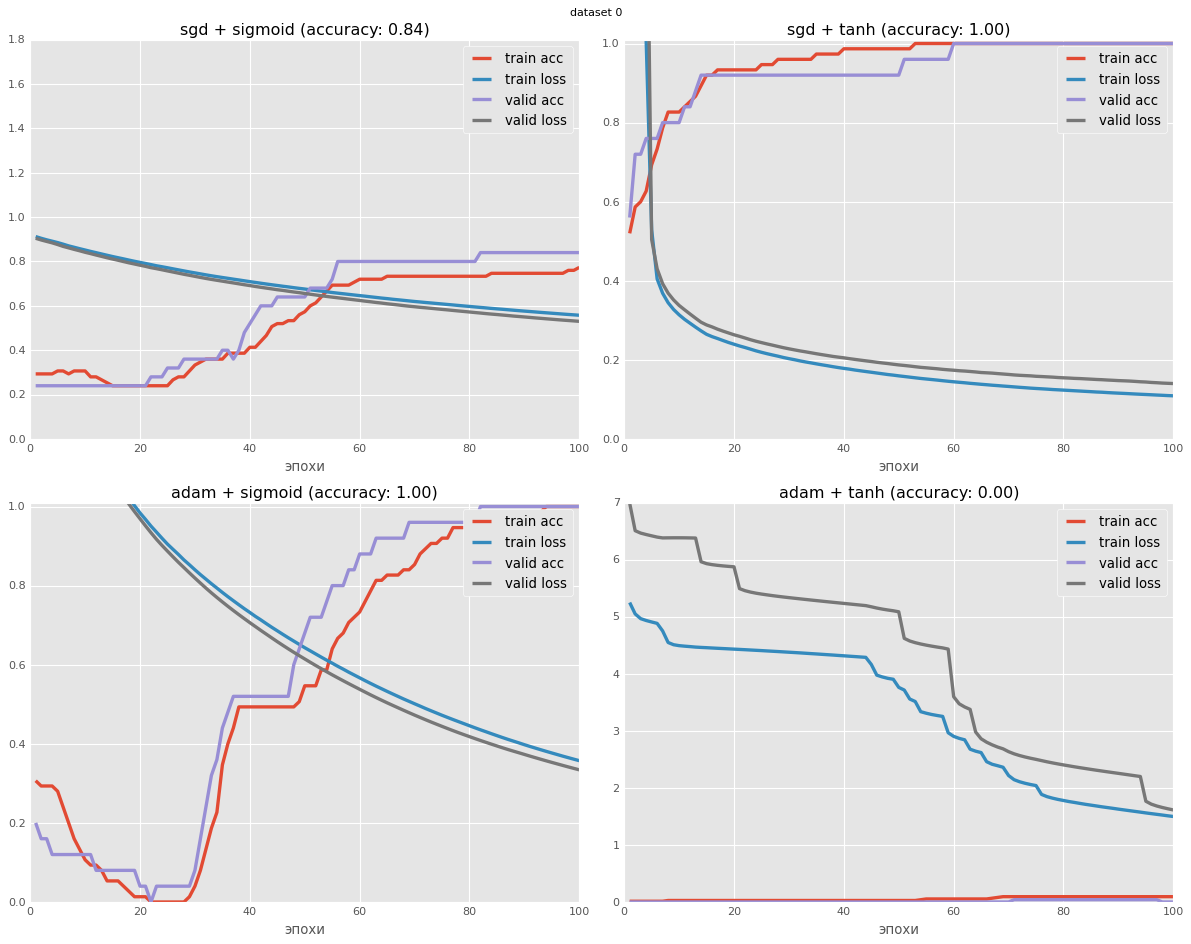

In [157]:
fig, axes = plt.subplots(2, 2, figsize=(15,12))
j = 0
for optimizer in ['sgd', 'adam']:
    i = 0
    for activation in ['sigmoid', 'tanh']:
        axes[j][i].plot(range(1, 101), train0[optimizer + '_' + activation]['accuracy'], label='train acc', linewidth=3)
        axes[j][i].plot(range(1, 101), train0[optimizer + '_' + activation]['loss'], label='train loss', linewidth=3)
        axes[j][i].plot(range(1, 101), train0[optimizer + '_' + activation]['val_accuracy'], label='valid acc', linewidth=3)
        axes[j][i].plot(range(1, 101), train0[optimizer + '_' + activation]['val_loss'], label='valid loss', linewidth=3)
        axes[j][i].set_title(optimizer + ' + ' + activation + f' (accuracy: {train0[optimizer + "_" + activation]["val_accuracy"][-1]:.2f})')
        #axes[j][i].grid()
        axes[j][i].legend()
        axes[j][i].set_xlabel('эпохи')
        i += 1
    j += 1
axes[0][0].set_ylim(0, 1.8)
axes[0][1].set_ylim(0, 1.01)
axes[1][0].set_ylim(0, 1.01)
#axes[1][1].set_ylim(0, 1.01)
plt.suptitle('dataset 0')
plt.tight_layout()
plt.show()

In [158]:
train1 = train_model(X_train1, y_train1, X_test1, y_test1, 0.001)

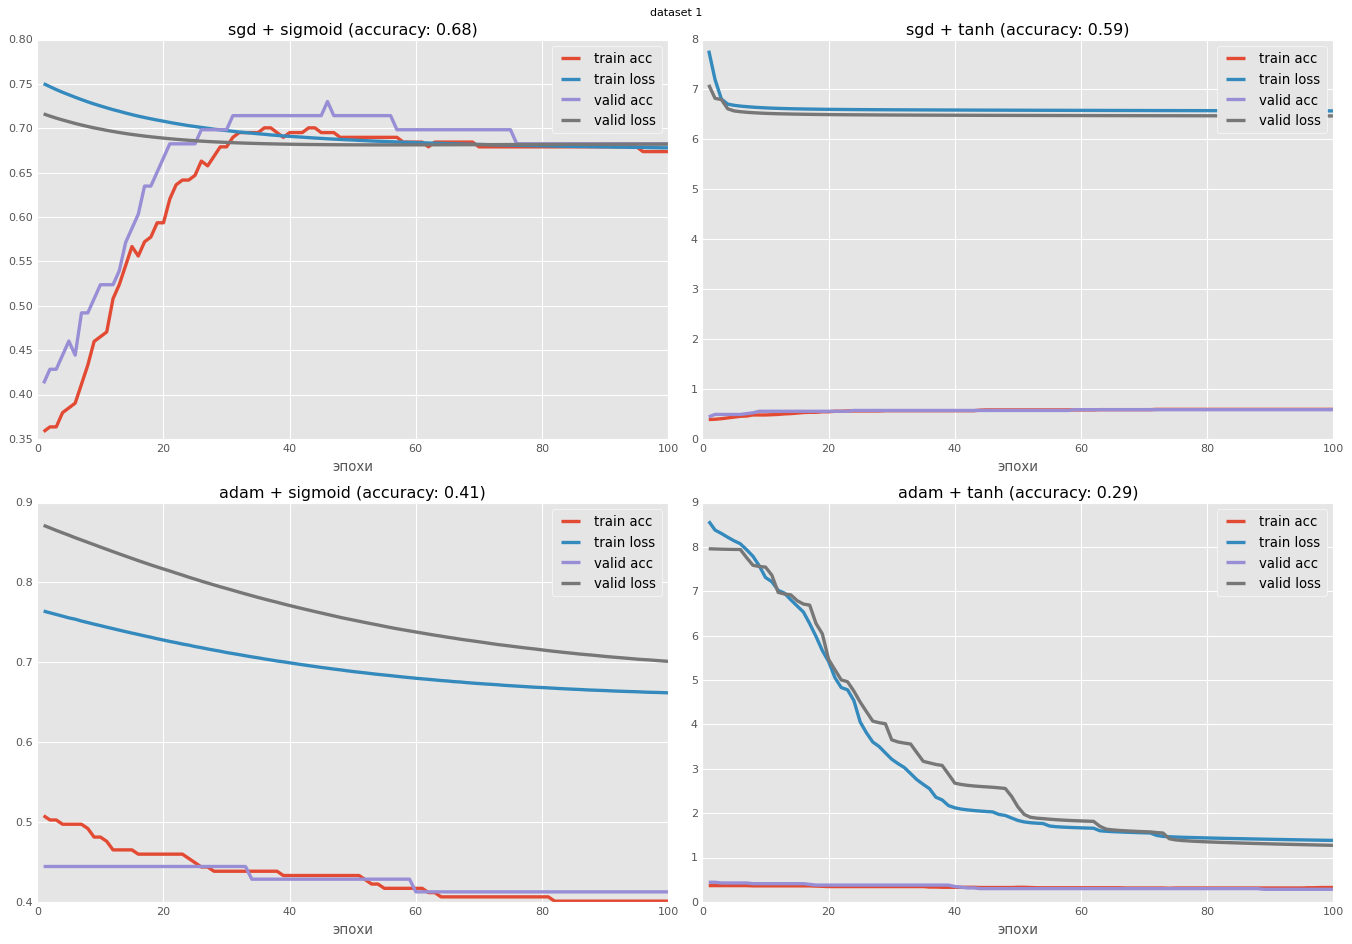

In [159]:
fig, axes = plt.subplots(2, 2, figsize=(17,12))
j = 0
for optimizer in ['sgd', 'adam']:
    i = 0
    for activation in ['sigmoid', 'tanh']:
        axes[j][i].plot(range(1, 101), train1[optimizer + '_' + activation]['accuracy'], label='train acc', linewidth=3)
        axes[j][i].plot(range(1, 101), train1[optimizer + '_' + activation]['loss'], label='train loss', linewidth=3)
        axes[j][i].plot(range(1, 101), train1[optimizer + '_' + activation]['val_accuracy'], label='valid acc', linewidth=3)
        axes[j][i].plot(range(1, 101), train1[optimizer + '_' + activation]['val_loss'], label='valid loss', linewidth=3)
        axes[j][i].set_title(optimizer + ' + ' + activation + f' (accuracy: {train1[optimizer + "_" + activation]["val_accuracy"][-1]:.2f})')
        axes[j][i].set_xlabel('эпохи')
       #axes[j][i].grid()
        axes[j][i].legend()
        i += 1
    j += 1
#axes[0][0].set_ylim(0.3, 1)
plt.suptitle('dataset 1')
plt.tight_layout()
plt.show()

## Задание 2

Постройте другую нейронную сеть, чтобы достичь минимальной ошибки на датасете nn_1.csv. Объясните выбор гиперпараметров построенной нейронной сети.

In [166]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Dense(4, input_dim=2, activation='relu'))
model2.add(keras.layers.Dense(4, activation='relu'))
model2.add(keras.layers.Dense(1, activation='sigmoid'))
model2.compile(loss='binary_crossentropy', optimizer=Adam(0.01), metrics=['accuracy'])
fit = model2.fit(X_train1, y_train1, verbose=0, epochs=50, validation_data=(X_test1, y_test1), shuffle=True).history

In [167]:
model2.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                     │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 113 (456.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 76 (308.00 B)

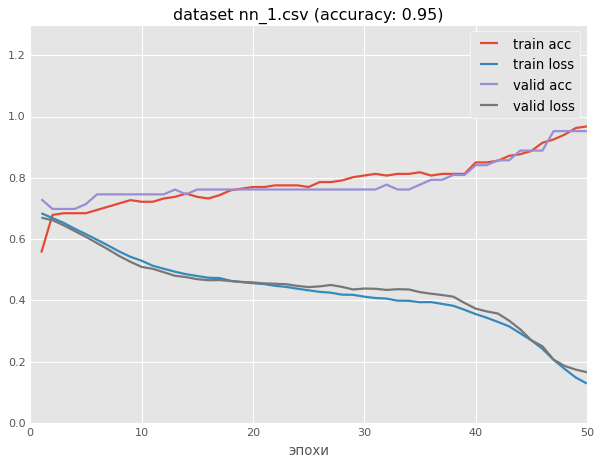

In [170]:
plt.plot(range(1, 51), fit['accuracy'], label='train acc', linewidth=2)
plt.plot(range(1, 51), fit['loss'], label='train loss', linewidth=2)
plt.plot(range(1, 51), fit['val_accuracy'], label='valid acc', linewidth=2)
plt.plot(range(1, 51), fit['val_loss'], label='valid loss', linewidth=2)
plt.ylim(0, 1.3)
plt.xlabel('эпохи')
plt.title('dataset nn_1.csv'f' (accuracy: {fit["val_accuracy"][-1]:.2f})')
#plt.grid()
plt.legend()

## Задание 3

In [56]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [57]:
X_train.shape

(60000, 28, 28)

- В данные не хватает размерности канала (он тут один, но свёрточные слои его требуют), добавим её
- Данные слеует нормализовать

In [58]:
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

In [171]:
model3 = keras.models.Sequential()

model3.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(28, 28, 1), padding='same', activation='relu'))
model3.add(AvgPool2D(pool_size=(2,2)))
model3.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model3.add(AvgPool2D(pool_size=(2,2)))
model3.add(Flatten())
model3.add(Dense(units=64, activation='relu'))
#model3.add(Dense(units=128, activation='relu'))
model3.add(Dense(units=10, activation='softmax'))

model3.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(0.001), metrics=['acc'])

model3.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 166,986 (652.29 KB)

 Trainable params: 166,986 (652.29 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
fit3 = model3.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, verbose=1).history

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9521 - loss: 0.1567 - val_acc: 0.9839 - val_loss: 0.0568
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9834 - loss: 0.0541 - val_acc: 0.9886 - val_loss: 0.0362
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9876 - loss: 0.0396 - val_acc: 0.9885 - val_loss: 0.0369
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9907 - loss: 0.0298 - val_acc: 0.9894 - val_loss: 0.0296
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9925 - loss: 0.0237 - val_acc: 0.9896 - val_loss: 0.0324


In [173]:
fit3['val_acc'][2]

0.9884999990463257

тут я чуть подогнал (взял результат 3 эпохи, а не последней), потому что могу

In [174]:
for layer in model3.layers:
    print(layer.name)

conv2d_4
average_pooling2d
conv2d_5
average_pooling2d_1
flatten_2
dense_47
dense_48


Визулизируем все фильтры из каждого свёрточного слоя по гайду из задания

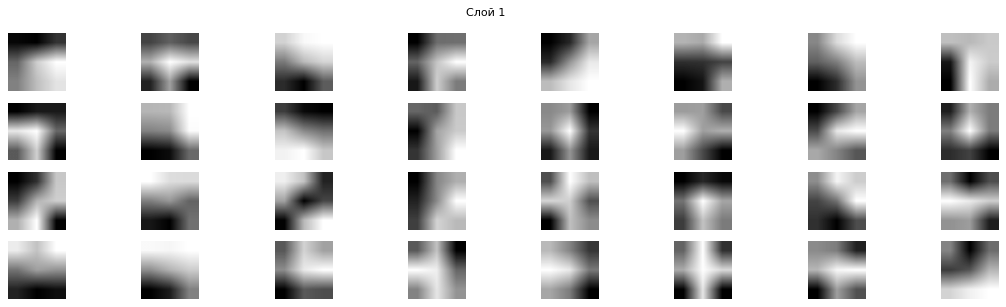

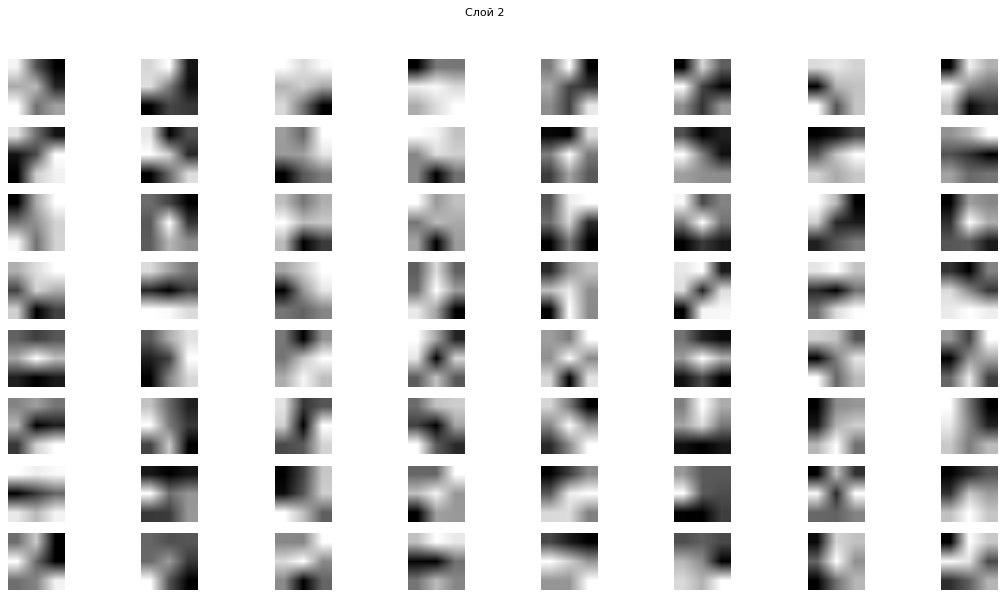

In [176]:
filters, bias = model3.layers[0].get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
fig = plt.figure(figsize=(15,4))
ix=1
for i in range(32):
    f = filters[:,:,:,i]
    plt.subplot(4, 8, ix)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')
    ix+=1
plt.suptitle('Слой 1')
plt.show()

filters, bias = model3.layers[2].get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
fig = plt.figure(figsize=(15,8))
ix=1
for i in range(64):
    f = filters[:,:,:,i]
    plt.subplot(8, 8, ix)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')
    ix+=1
plt.suptitle('Слой 2')
plt.show()

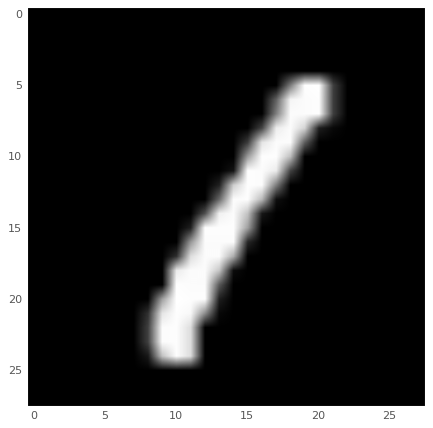

In [177]:
plt.imshow(X_train[3], cmap='gray')
plt.grid()

In [178]:
sub_model = keras.models.Model(inputs=model3.inputs, outputs=model3.layers[0].output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


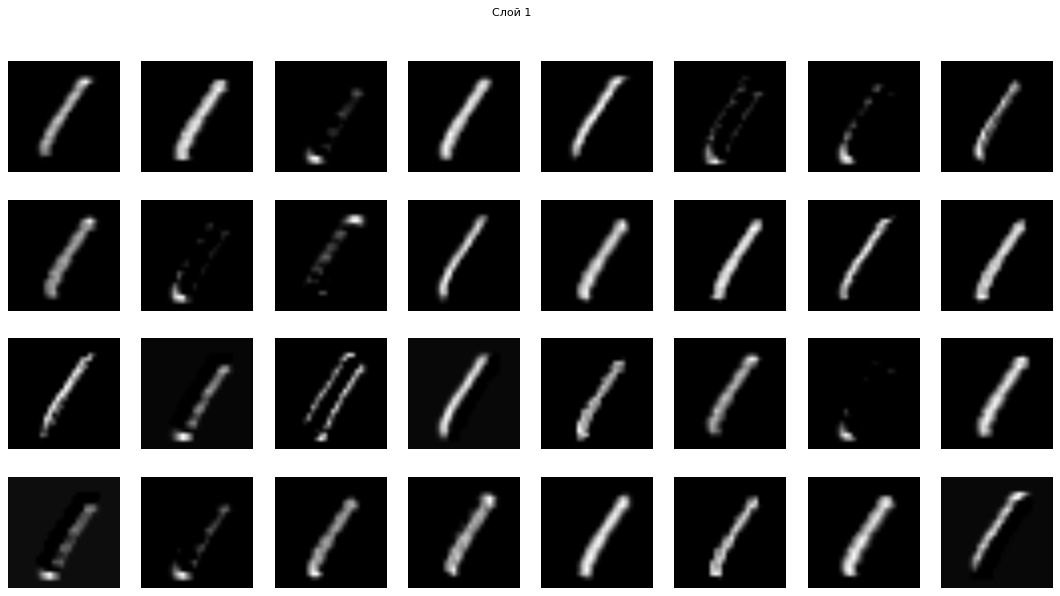

In [179]:
sample = X_train[3].reshape(-1, 28, 28, 1)
features = sub_model.predict(sample)

fig = plt.figure(figsize=(15,8))
for i in range(1, 33):
    plt.subplot(4, 8, i)
    #feature = features[0, :, :, i-1]
    #feature = (feature - feature.min()) / (feature.max() - feature.min())
    plt.imshow(features[0, :, :, i-1], cmap='gray')
    plt.axis('off')
plt.suptitle('Слой 1')
plt.show()

In [180]:
sub_model = keras.models.Model(inputs=model3.inputs, outputs=model3.layers[2].output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


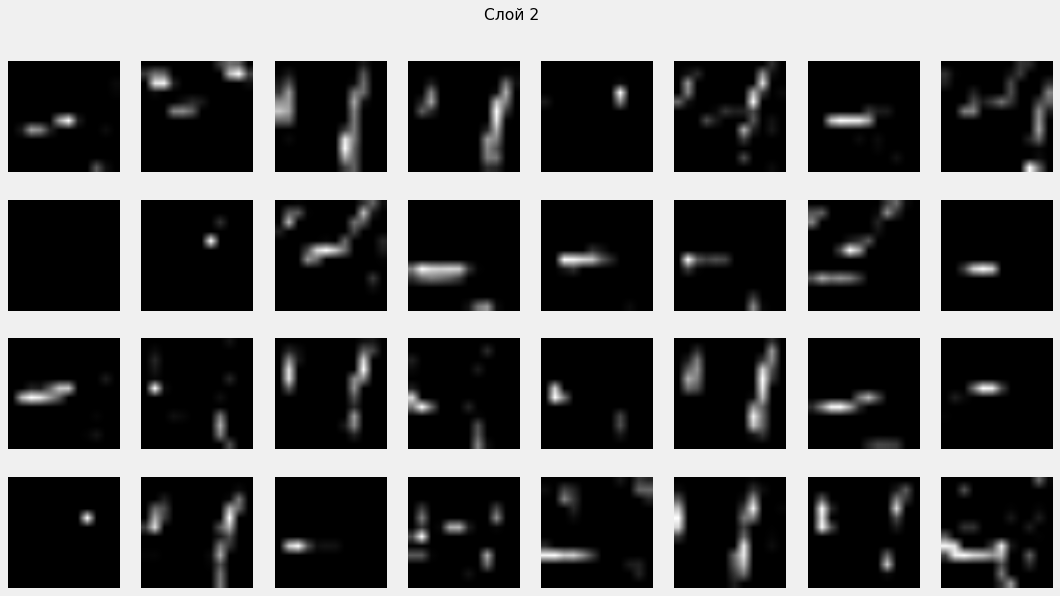

In [145]:
sample = X_train[3].reshape(-1, 28, 28, 1)
features = sub_model.predict(sample)

fig = plt.figure(figsize=(15,8))
for i in range(1, 33):
    plt.subplot(4, 8, i)
    plt.imshow(features[0, :, :, i-1], cmap='gray')
    plt.axis('off')
plt.suptitle('Слой 2')
plt.show()